<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

In [1]:
import torch
import torch.nn as nn
import numpy as np
from typing import Union
from transformers import AutoModel, AutoConfig, AutoTokenizer
from datasets import Dataset

In [ ]:
# !pip install evaluate scikit-learn

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [3]:
class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int):
      super().__init__()
      if isinstance(base_transformer_model, str):
        self.backbone = AutoModel.from_pretrained(base_transformer_model)
      else:
        self.backbone = base_transformer_model
        self.backbone.config.output_attentions = True

      self.in_features = self.backbone.config.hidden_size
      self.classifier = nn.Linear(self.in_features, num_classes)

      self.loss_fct = nn.CrossEntropyLoss()


    def forward(self, input_ids=None, attention_mask=None, labels=None, output_attentions=False, **kwargs):
      raw_outputs = self.backbone(input_ids=input_ids,
                                  attention_mask=attention_mask,
                                  output_attentions=output_attentions,
                                  **kwargs)
      sequence_output = raw_outputs.last_hidden_state

      cls_token_vector = sequence_output[:, 0, :]
      logits = self.classifier(cls_token_vector)

      loss = None
      if labels is not None:
        loss = self.loss_fct(logits.view(-1, self.classifier.out_features), labels.view(-1))

      output = {"logits": logits}
      if loss is not None:
        output["loss"] = loss

      if output_attentions:

        output["attentions"] = raw_outputs.attentions # это кортеж тензоров для каждого слоя

      # Выделяем вектор первого токена (индекс 0) для классификации
      return output


### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [4]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [5]:
import evaluate
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [27]:
import os
os.environ["SAFETENSORS_VARIANT"] = "false"
os.environ["TRANSFORMERS_NO_ADAPTERS"] = "true"

In [30]:
import copy
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

def train_transformer(transformer_model, tokenized_dataset, tokenizer, freeze_backbone=True):
    model = transformer_model
    if freeze_backbone:
      model = freeze_backbone_function(transformer_model)

    for param in model.parameters(): #из-за ерроров при обучении
        if param.requires_grad:
            param.data = param.data.contiguous()

    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8, # можно чуть больше для классификации
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.01,
        save_total_limit=3,
        report_to="none",
        load_best_model_at_end=True,
        remove_unused_columns=False,
    )
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    trainer.train()
    return model

In [34]:
import torch
import copy
import os
os.environ["TRANSFORMERS_NO_ADAPTERS"] = "true"

from transformers import Trainer, TrainingArguments, DataCollatorWithPadding


class SafeSaveTrainer(Trainer):
    """Trainer, который делает все тензоры contiguous перед сохранением чекпоинта."""

    def _save(self, output_dir=None, state_dict=None):
        # Делаем копию state_dict и приводим все тензоры к contiguous
        if state_dict is None:
            state_dict = self.model.state_dict()

        contiguous_state_dict = {}
        for key, tensor in state_dict.items():
            contiguous_state_dict[key] = tensor.contiguous()

        super()._save(output_dir=output_dir, state_dict=contiguous_state_dict)


def train_transformer(transformer_model, tokenized_dataset, tokenizer, freeze_backbone=True):
    model = transformer_model

    if freeze_backbone:
        model = freeze_backbone_function(transformer_model)

    # Приводим веса к contiguous сразу после загрузки/заморозки
    for param in model.parameters():
        param.data = param.data.contiguous()

    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.01,
        save_total_limit=3,
        report_to="none",
        load_best_model_at_end=True,
        remove_unused_columns=False,
        # Отключаем смешанную точность — AMP создаёт non-contiguous тензоры
        fp16=False,
        bf16=False,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = SafeSaveTrainer(              # <-- SafeSaveTrainer вместо Trainer
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return model


### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

### для начала подготовим данные

In [7]:
import pandas as pd
df = pd.read_excel("/content/data_problems_translated.xlsx", index_col=0)
df.head(6)

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs
5,"If the number is the whole, the number is the ...",number_theory


In [8]:
print(df.info())
df[df['problem_text'].isnull()]

<class 'pandas.core.frame.DataFrame'>
Index: 5273 entries, 0 to 5272
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   problem_text  5268 non-null   object
 1   topic         5273 non-null   object
dtypes: object(2)
memory usage: 123.6+ KB
None


,problem_text,topic
1892,NaN,geometry
2052,NaN,polynoms
2724,NaN,number_theory
3473,NaN,geometry
4072,NaN,geometry


In [9]:
df_clean = df.dropna(subset=['problem_text']).reset_index(drop=True)
df_clean.info()
num_classes = len(df_clean['topic'].unique())
print(num_classes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   problem_text  5268 non-null   object
 1   topic         5268 non-null   object
dtypes: object(2)
memory usage: 82.4+ KB
7


In [10]:
dataset = Dataset.from_pandas(df_clean)
dataset = dataset.train_test_split(test_size=0.2)
dataset

DatasetDict({
    train: Dataset({
        features: ['problem_text', 'topic'],
        num_rows: 4214
    })
    test: Dataset({
        features: ['problem_text', 'topic'],
        num_rows: 1054
    })
})

In [11]:
keys = df['topic'].unique()
values = range(len(keys))

### Выполняем задание

In [12]:
label2id = dict(zip(keys, values))

def preprocess_function(examples):
    model_inputs = rubert_tiny_tokenizer(examples["problem_text"], max_length=1024, truncation=True)
    model_inputs["labels"] = [label2id[topic] for topic in examples['topic']]
    return model_inputs

rubert_tiny_model_id = 'cointegrated/rubert-tiny2'
rubert_tiny_tokenizer = AutoTokenizer.from_pretrained(rubert_tiny_model_id)
tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)

rubert_tiny_transformer_model = TransformerClassificationModel(rubert_tiny_model_id , num_classes)
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, tokenized_dataset, rubert_tiny_tokenizer, freeze_backbone=True)

rubert_tiny_transformer_model = TransformerClassificationModel(rubert_tiny_model_id , num_classes)
rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, tokenized_dataset, rubert_tiny_tokenizer, freeze_backbone=False)

Map:   0%|          | 0/4214 [00:00<?, ? examples/s]

Map:   0%|          | 0/1054 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.795787,1.687850,0.441176
2,1.640859,1.604434,0.444023
3,1.583605,1.570655,0.444023
4,1.559039,1.554636,0.444972
5,1.543424,1.549948,0.445920


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.333285,1.072463,0.608159
2,1.063284,0.952594,0.645161
3,0.964161,0.917303,0.642315
4,0.917680,0.903283,0.648008
5,0.868098,0.899588,0.642315


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [35]:
def preprocess_function(examples):
    model_inputs = mathBert_tokenizer(
        examples["problem_text"],
        max_length=512,        # было 1024
        truncation=True
    )
    model_inputs["labels"] = [label2id[topic] for topic in examples["topic"]]
    return model_inputs

mathBert_model_id = 'tbs17/MathBert'
mathBert_tokenizer = AutoTokenizer.from_pretrained(mathBert_model_id)
tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)
mathBert_transformer_model = TransformerClassificationModel(mathBert_model_id , num_classes)
mathBert_finetuned_with_freezed_backbone = train_transformer(mathBert_transformer_model, tokenized_dataset, mathBert_tokenizer, freeze_backbone=True)

mathBert_transformer_model = TransformerClassificationModel(mathBert_model_id , num_classes)
mathBert_full_finetuned = train_transformer(mathBert_transformer_model, tokenized_dataset, mathBert_tokenizer, freeze_backbone=False)
### YOUR CODE IS HERE (probably, similar on the previous step)

Map:   0%|          | 0/4214 [00:00<?, ? examples/s]

Map:   0%|          | 0/1054 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.673447,1.596858,0.437381
2,1.554331,1.545888,0.443074
3,1.522988,1.509304,0.444023
4,1.506814,1.491960,0.444972
5,1.486946,1.486019,0.445920


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.194526,0.958301,0.635674
2,0.845367,0.947731,0.602467
3,0.639403,1.122455,0.592030
4,0.513694,1.231875,0.593928
5,0.399217,1.318506,0.589184


### Выводы по заданию
Лучший результат – rubert‑tiny2 с полным дообучением (Accuracy 64.8%, Validation Loss 0.903).
Почему:

rubert‑tiny2 лёгкий и хорошо решает эту задачу

MathBert не подходит для данной тематики (хотя и обучен на математических текстах).

Обычный BERT переобучается – модель слишком большая для объёма данных.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List


def draw_first_layer_attention_maps(
    attention_head_ids: List[int],
    text: str,
    model: TransformerClassificationModel,
    tokenizer=None,
    figsize_per_head=(8, 6),
    cmap="YlOrRd",
):
    device = next(model.parameters()).device

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    # ---------- Перезагружаем backbone с attn_implementation="eager" ----------
    from transformers import AutoConfig, AutoModel

    config = AutoConfig.from_pretrained(model.backbone.name_or_path)
    config.output_attentions = True

    backbone_eager = AutoModel.from_pretrained(
        model.backbone.name_or_path,
        config=config,
        attn_implementation="eager",
    ).to(device)

    # Копируем обученные веса из текущего backbone
    backbone_eager.load_state_dict(model.backbone.state_dict())
    backbone_eager.eval()

    # ---------- Прямой проход ----------
    with torch.no_grad():
        raw_outputs = backbone_eager(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
        )

    if raw_outputs.attentions is None:
        raise RuntimeError("Backbone не вернул карты внимания.")

    first_layer_attn = raw_outputs.attentions[0].squeeze(0)  # (num_heads, seq, seq)

    # ---------- Проверка индексов голов ----------
    num_heads = first_layer_attn.shape[0]
    for h_id in attention_head_ids:
        if h_id < 0 or h_id >= num_heads:
            raise ValueError(
                f"Голова {h_id} не существует. "
                f"Доступно голов: 0..{num_heads - 1}"
            )

    # ---------- Токены для подписей ----------
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

    # ---------- Отрисовка ----------
    n_heads = len(attention_head_ids)
    ncols = min(n_heads, 3)
    nrows = (n_heads + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_head[0] * ncols, figsize_per_head[1] * nrows),
        squeeze=False,
    )

    for idx, head_id in enumerate(attention_head_ids):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        attn_matrix = first_layer_attn[head_id].cpu().numpy()

        display_tokens = [
            t if len(t) <= 12 else t[:10] + ".." for t in tokens
        ]
        max_show = 64
        if attn_matrix.shape[0] > max_show:
            attn_matrix = attn_matrix[:max_show, :max_show]
            display_tokens = display_tokens[:max_show]

        sns.heatmap(
            attn_matrix,
            xticklabels=display_tokens,
            yticklabels=display_tokens,
            cmap=cmap,
            ax=ax,
            cbar=True,
            square=True,
            vmin=0.0,
            vmax=1.0,
        )
        ax.set_title(f"Layer 0 — Head {head_id}", fontsize=12, pad=8)
        ax.set_xlabel("Key tokens")
        ax.set_ylabel("Query tokens")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", rotation=0, labelsize=7)

    # Скрываем пустые подграфики
    total_cells = nrows * ncols
    for idx in range(n_heads, total_cells):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    fig.suptitle(
        f"Attention Maps — First Layer | «{text[:60]}{'…' if len(text) > 60 else ''}»",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
    return fig


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [38]:
small_dataset = dataset['test'].select([8, 102, 12])
small_dataset[0]

{'problem_text': 'Are there such natural numbers a1 < a2 < a3 <... < a100 that NOC(a1, a2) > NOC(a2, a3) > > NOC(a99, a100)?',
 'topic': 'number_theory'}

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


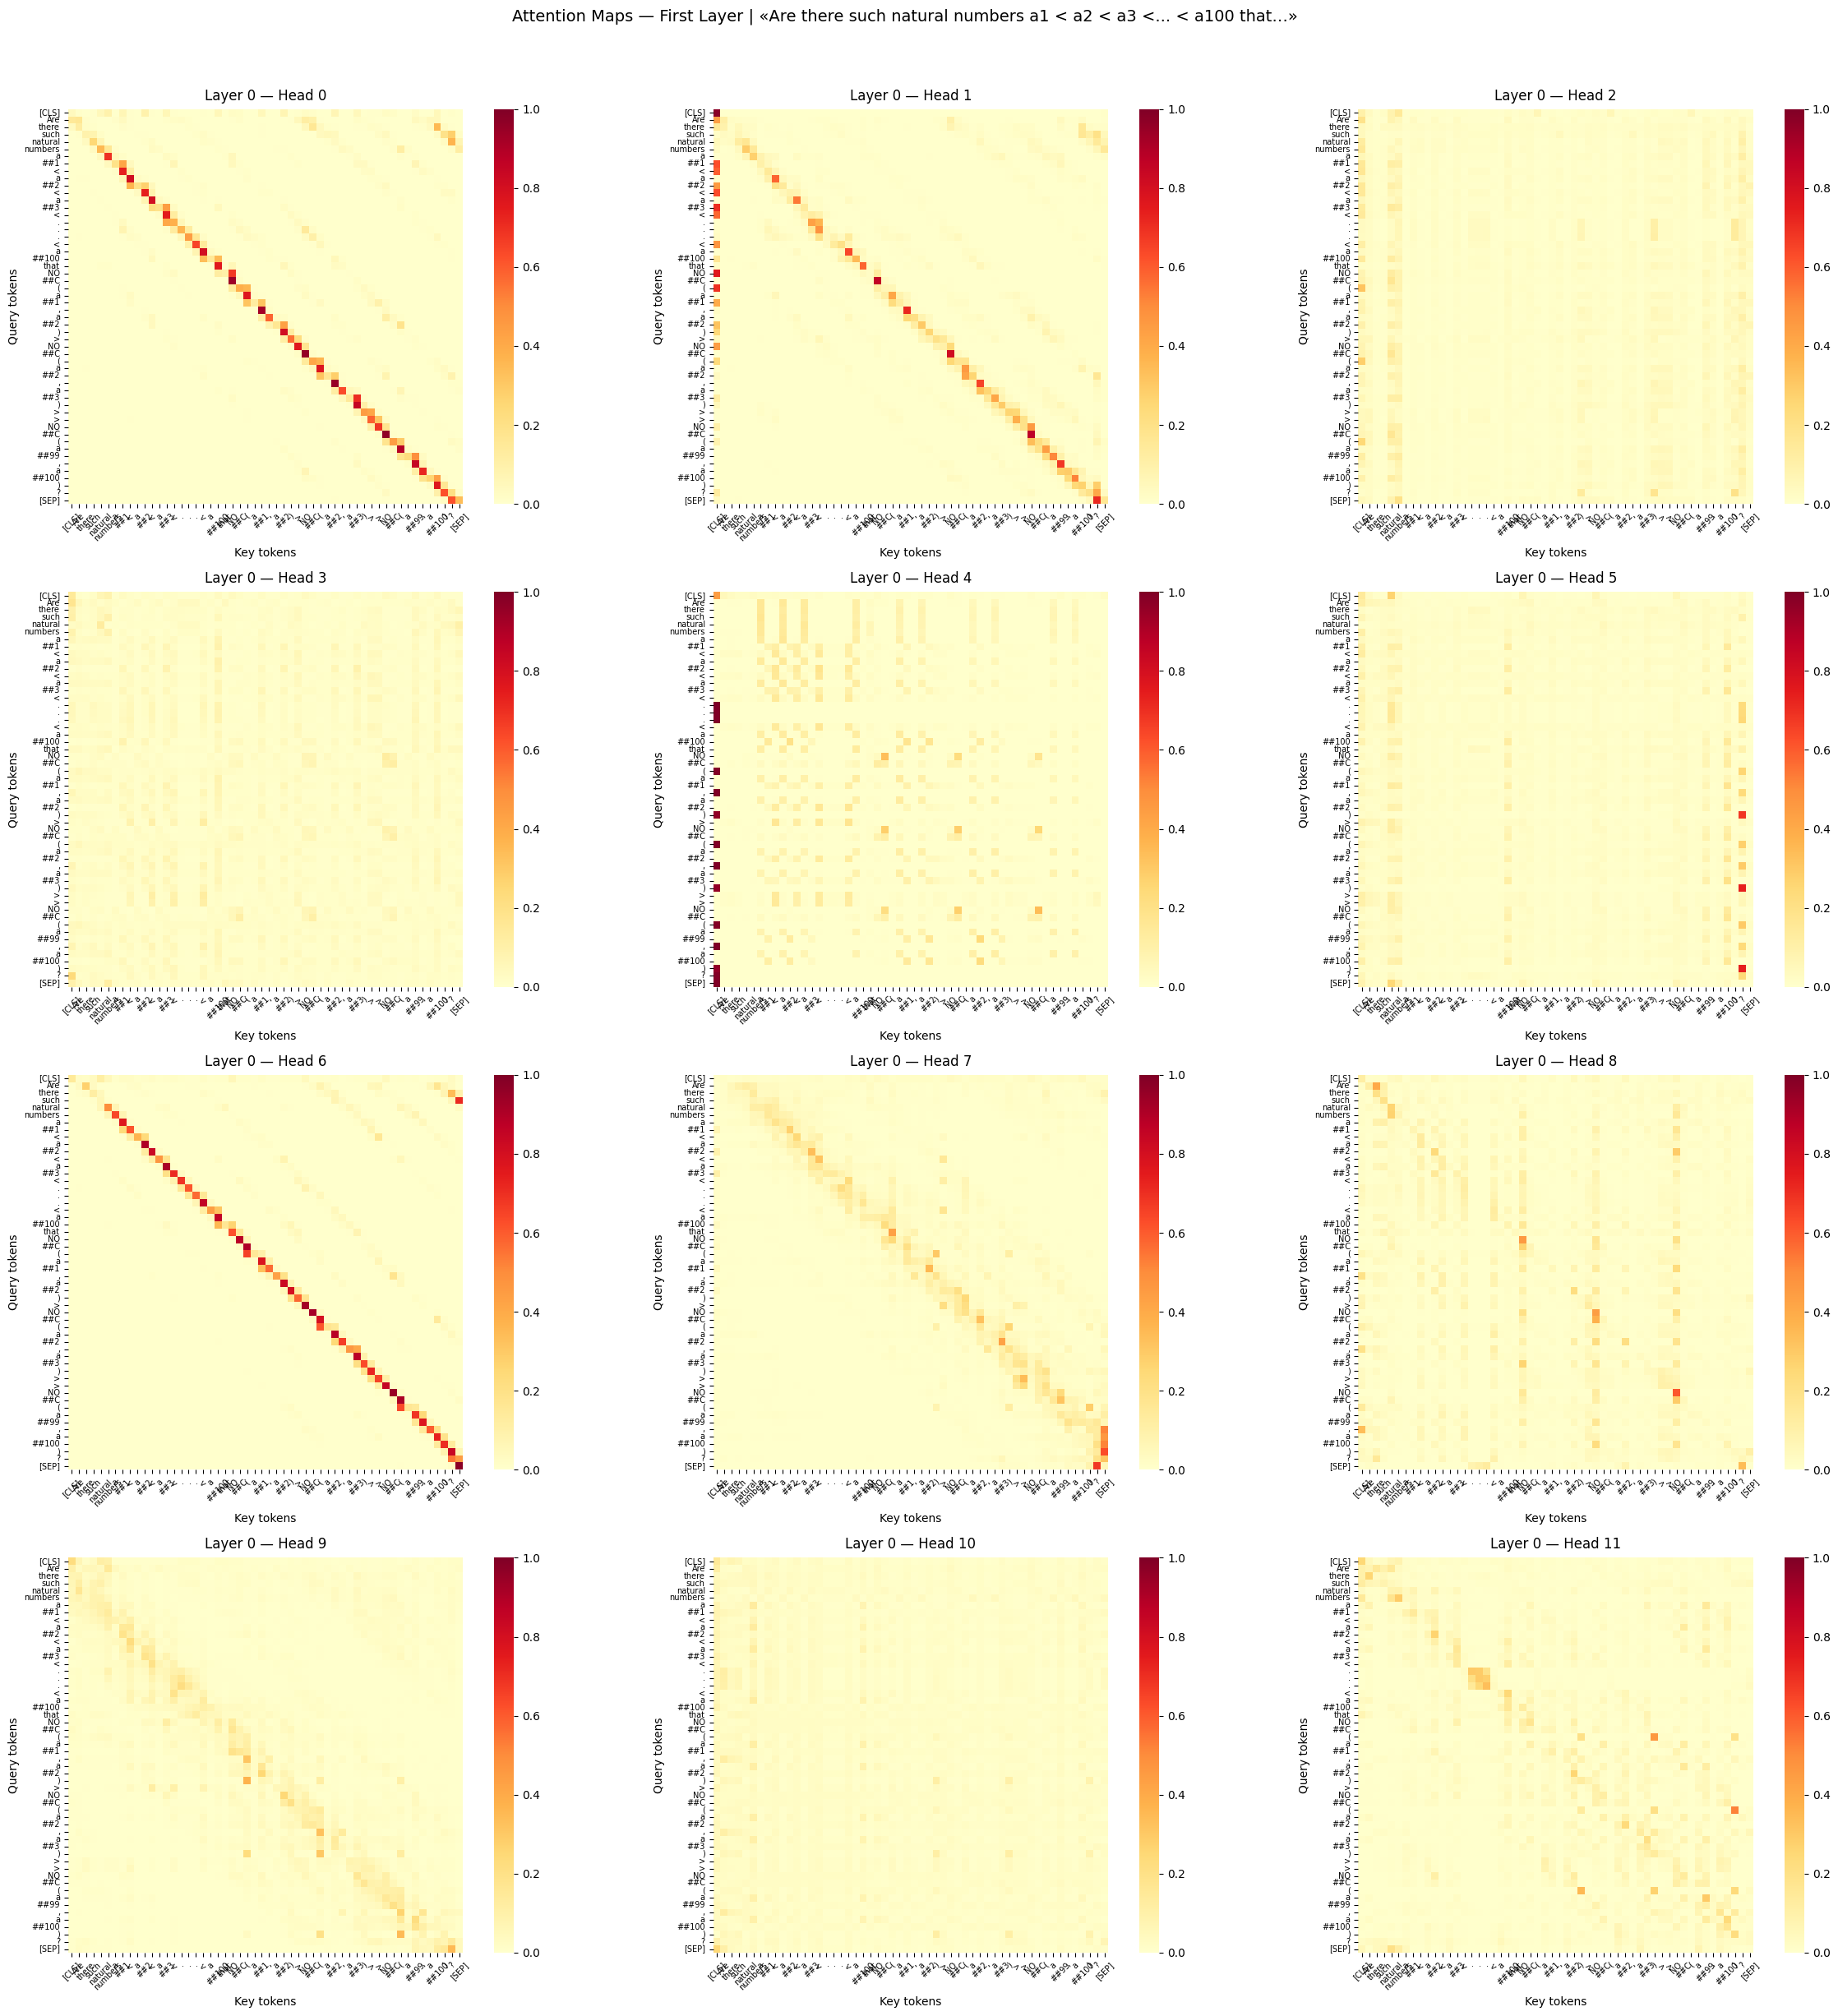

In [40]:
row_rubert_tiny_transformer_model = TransformerClassificationModel(rubert_tiny_model_id , num_classes)
#draw_first_layer_attention_maps(list(range(12)), small_dataset[0]['problem_text'], row_rubert_tiny_transformer_model, rubert_tiny_tokenizer)
fig = draw_first_layer_attention_maps(
    attention_head_ids=list(range(12)),    # головы для визуализации
    text=small_dataset[0]['problem_text'],
    model=row_rubert_tiny_transformer_model,
    tokenizer=rubert_tiny_tokenizer,
    cmap="YlOrRd",
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


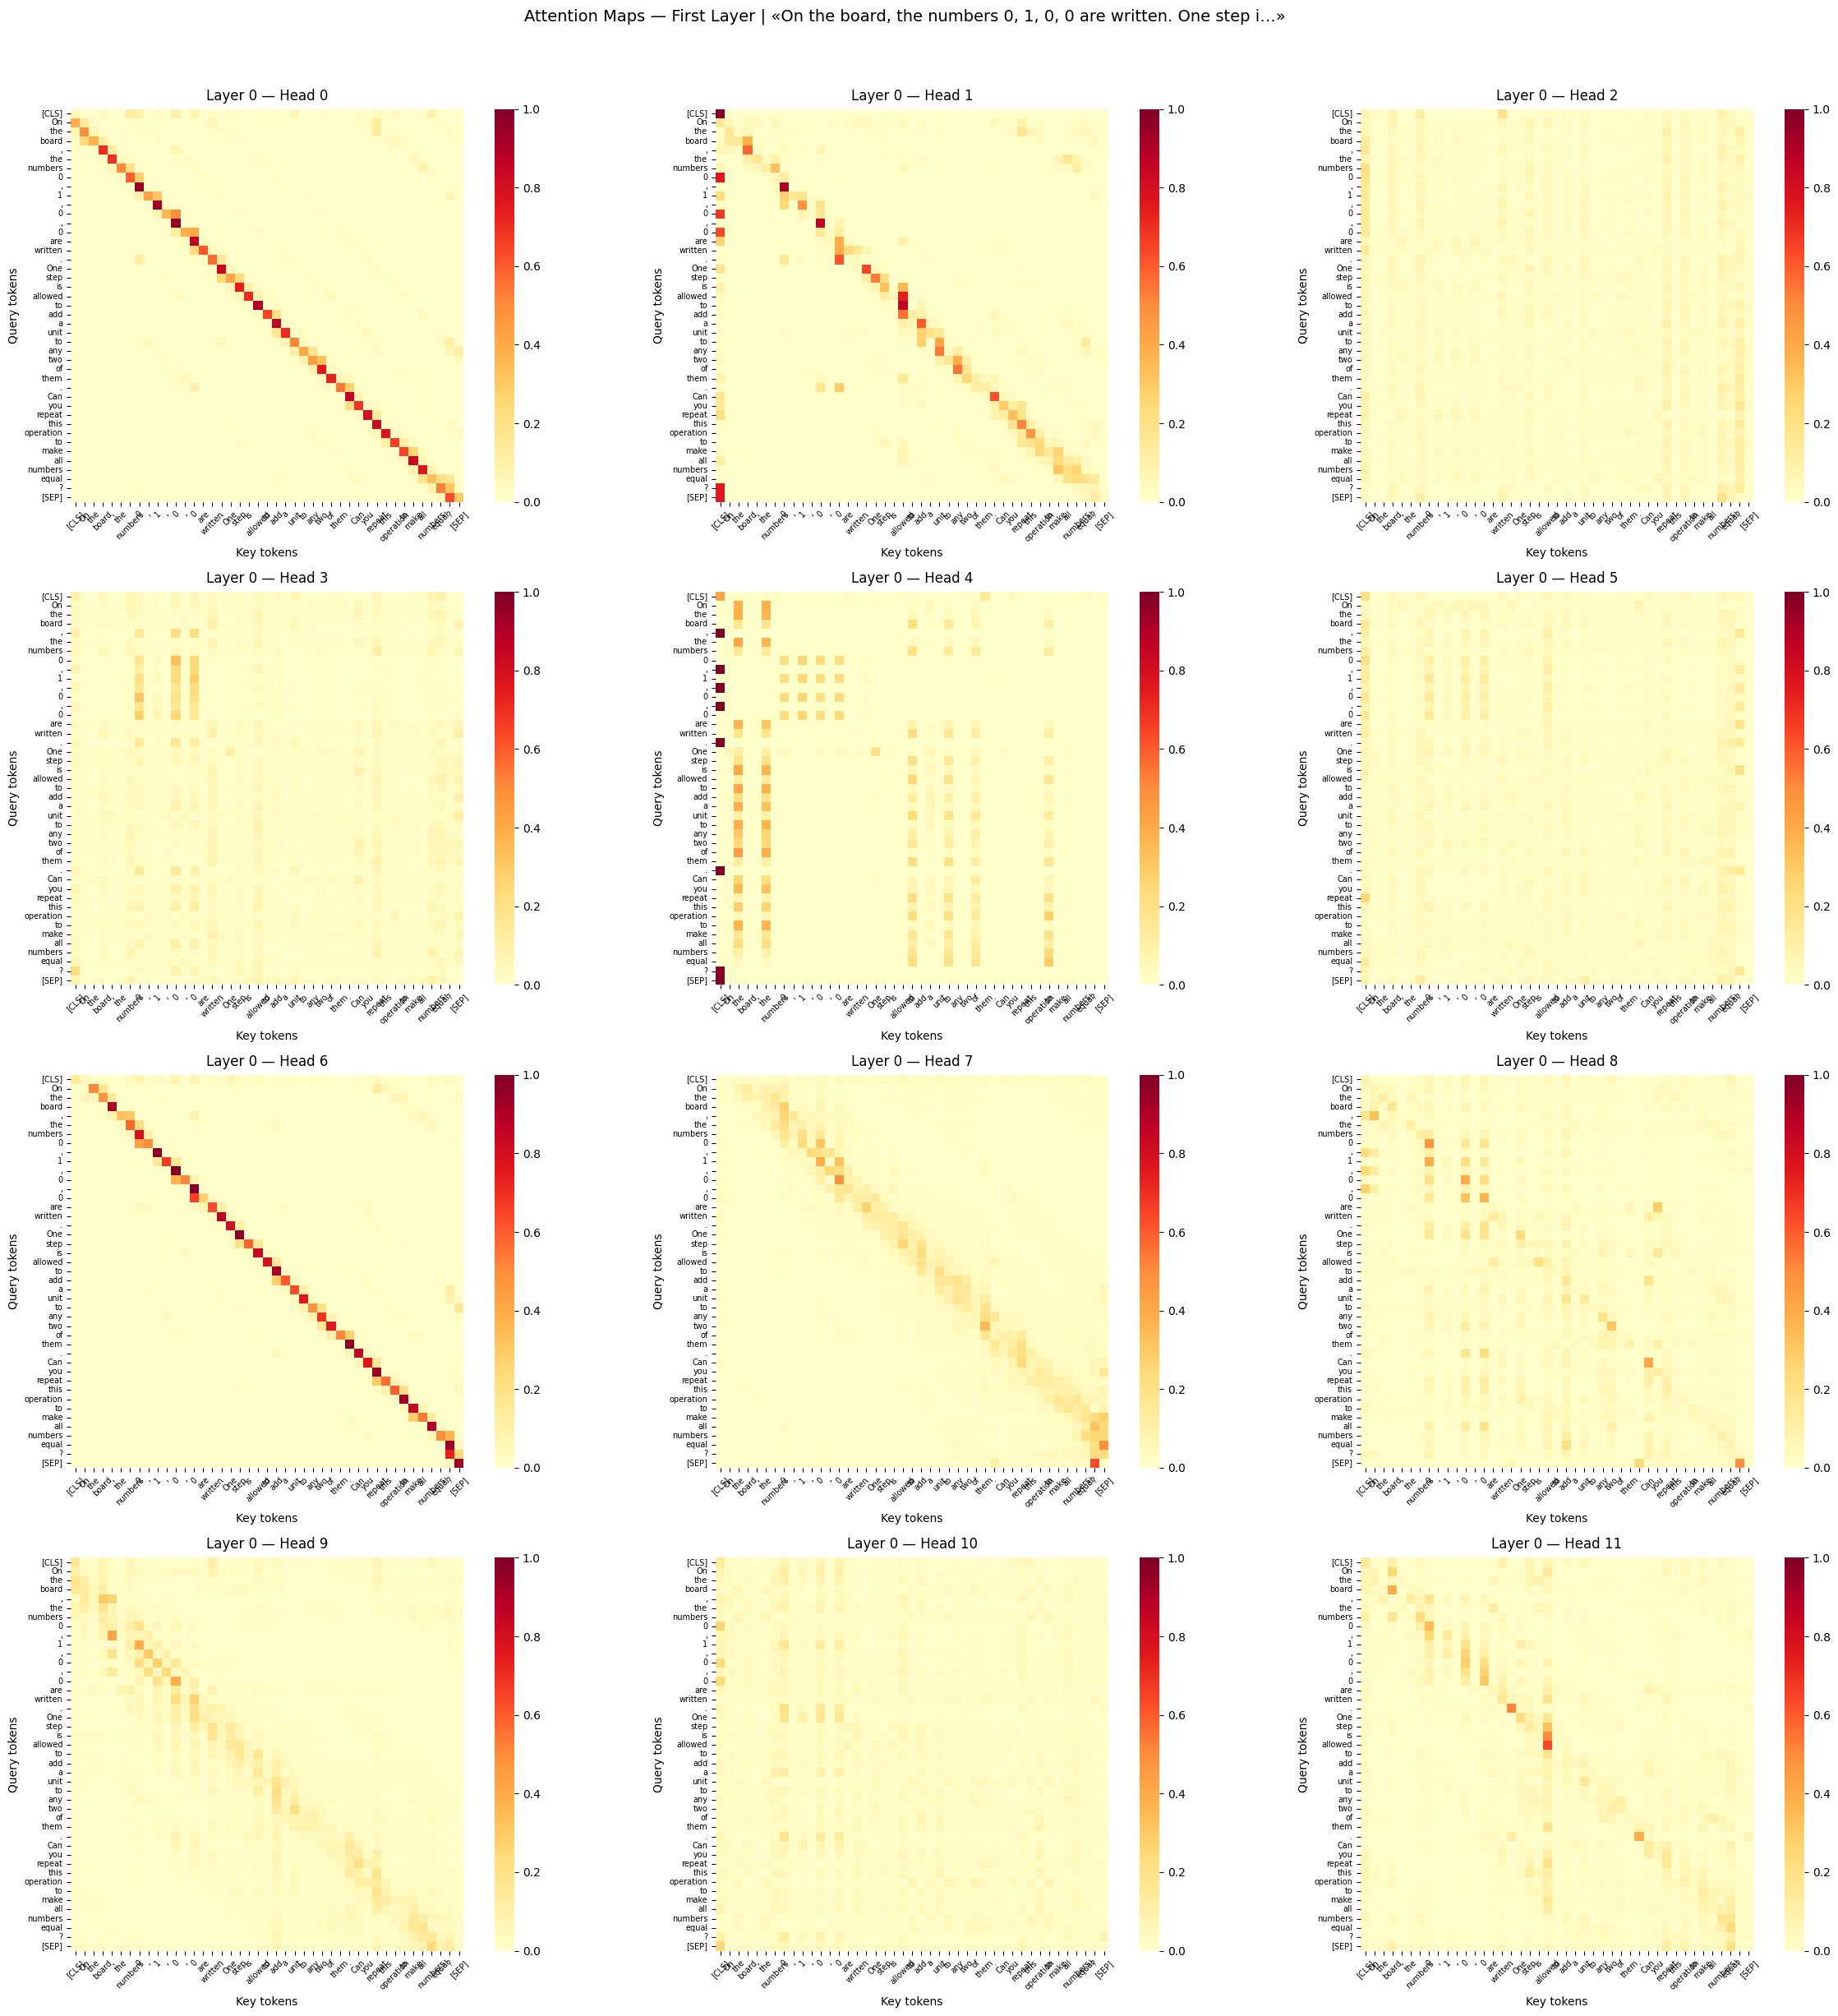

In [41]:
fig = draw_first_layer_attention_maps(
    attention_head_ids=list(range(12)),    # головы для визуализации
    text=small_dataset[1]['problem_text'],
    model=row_rubert_tiny_transformer_model,
    tokenizer=rubert_tiny_tokenizer,
    cmap="YlOrRd",
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


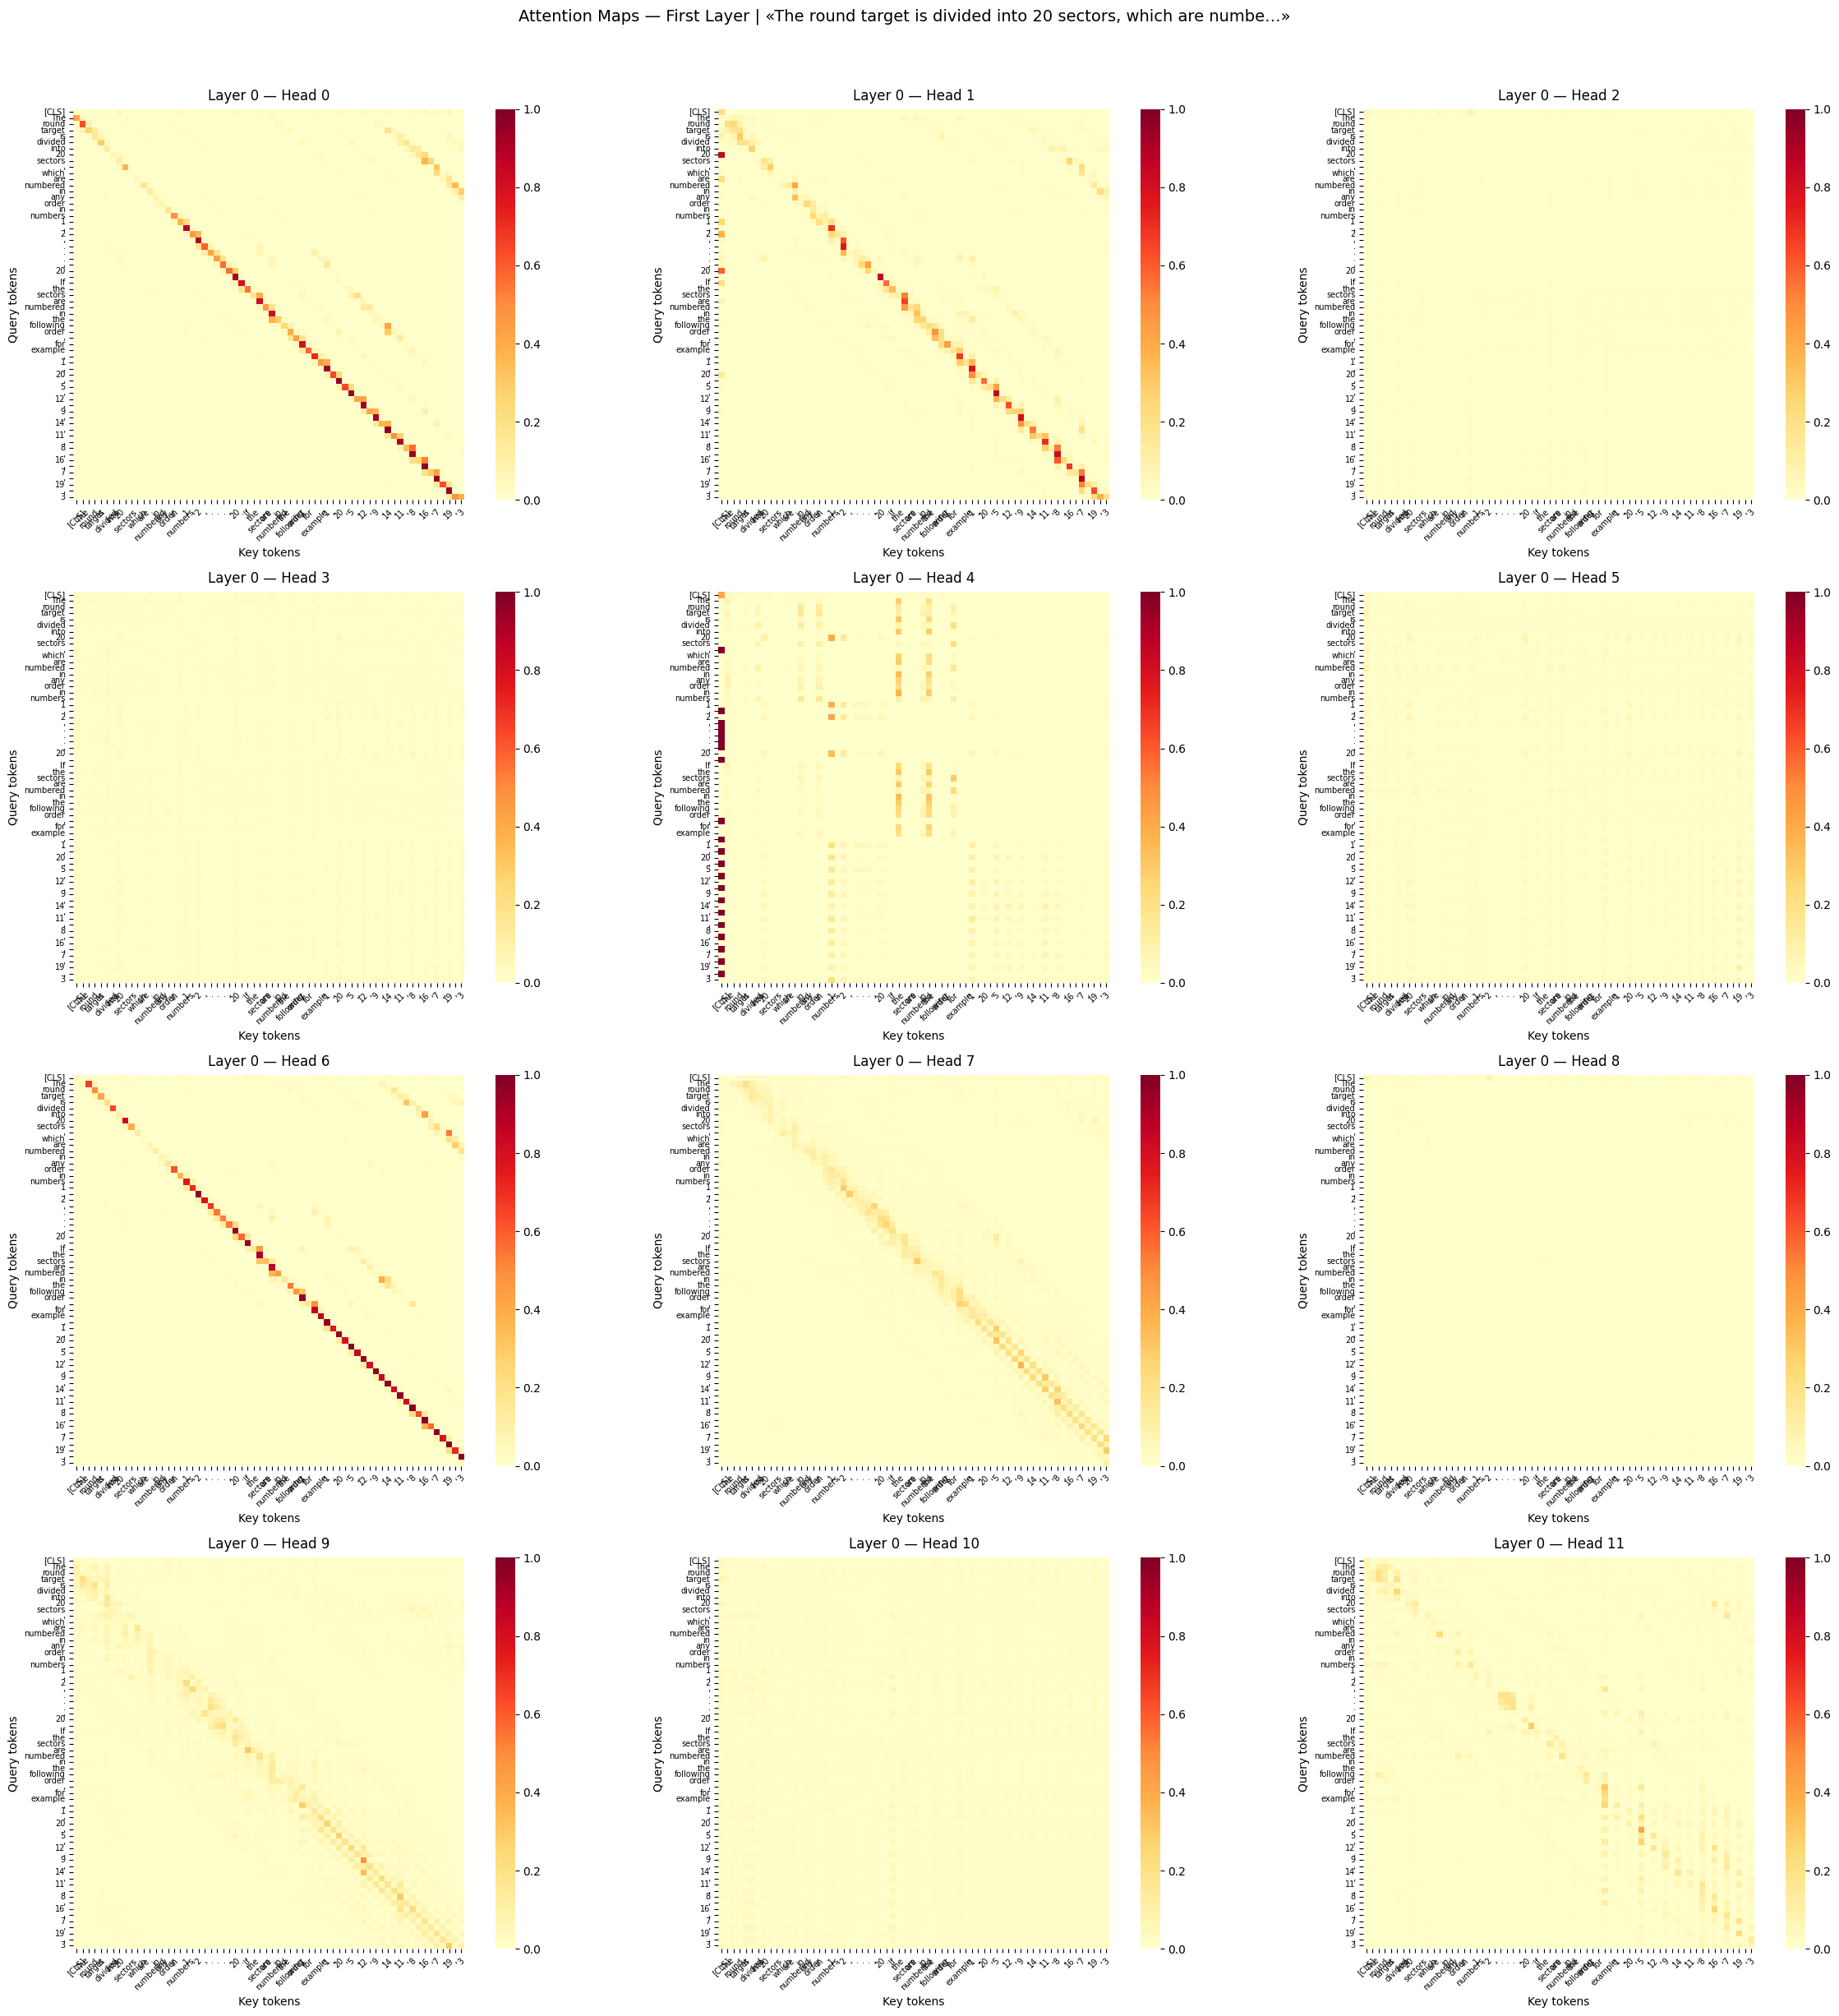

In [42]:
fig = draw_first_layer_attention_maps(
    attention_head_ids=list(range(12)),    # головы для визуализации
    text=small_dataset[2]['problem_text'],
    model=row_rubert_tiny_transformer_model,
    tokenizer=rubert_tiny_tokenizer,
    cmap="YlOrRd",
)

In [43]:
row_mathBert_model = TransformerClassificationModel(mathBert_model_id , num_classes)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


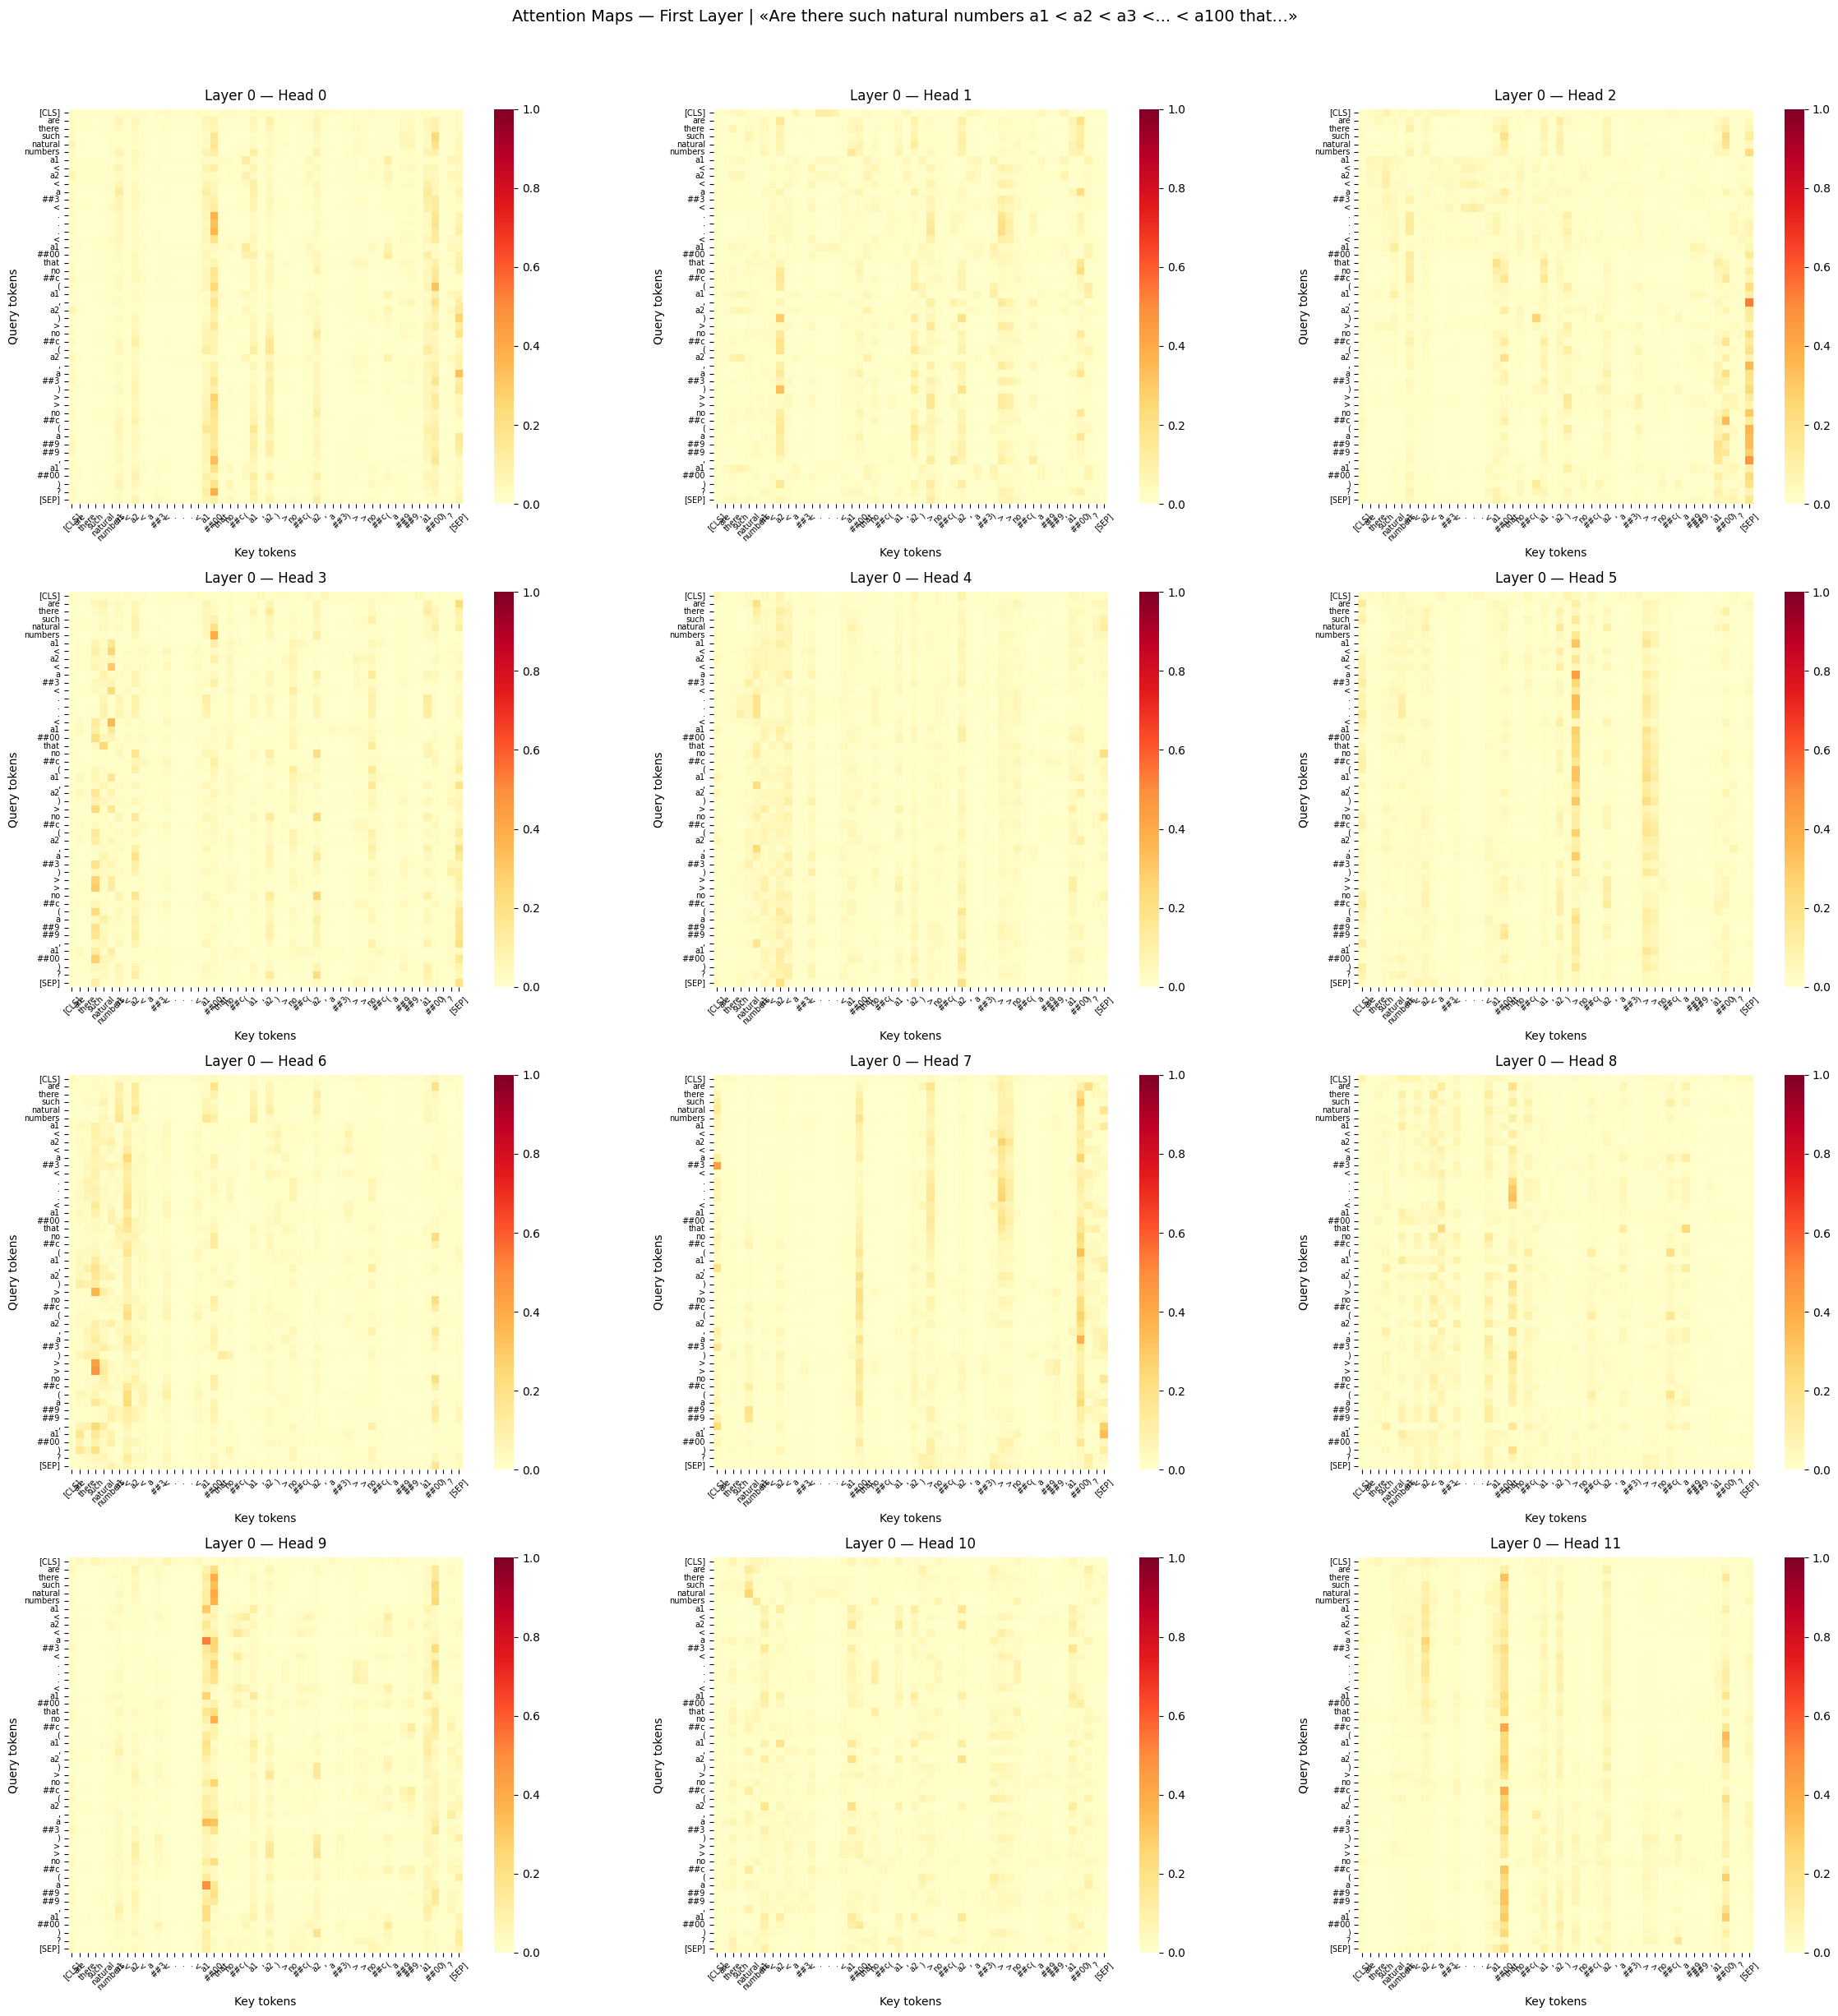

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


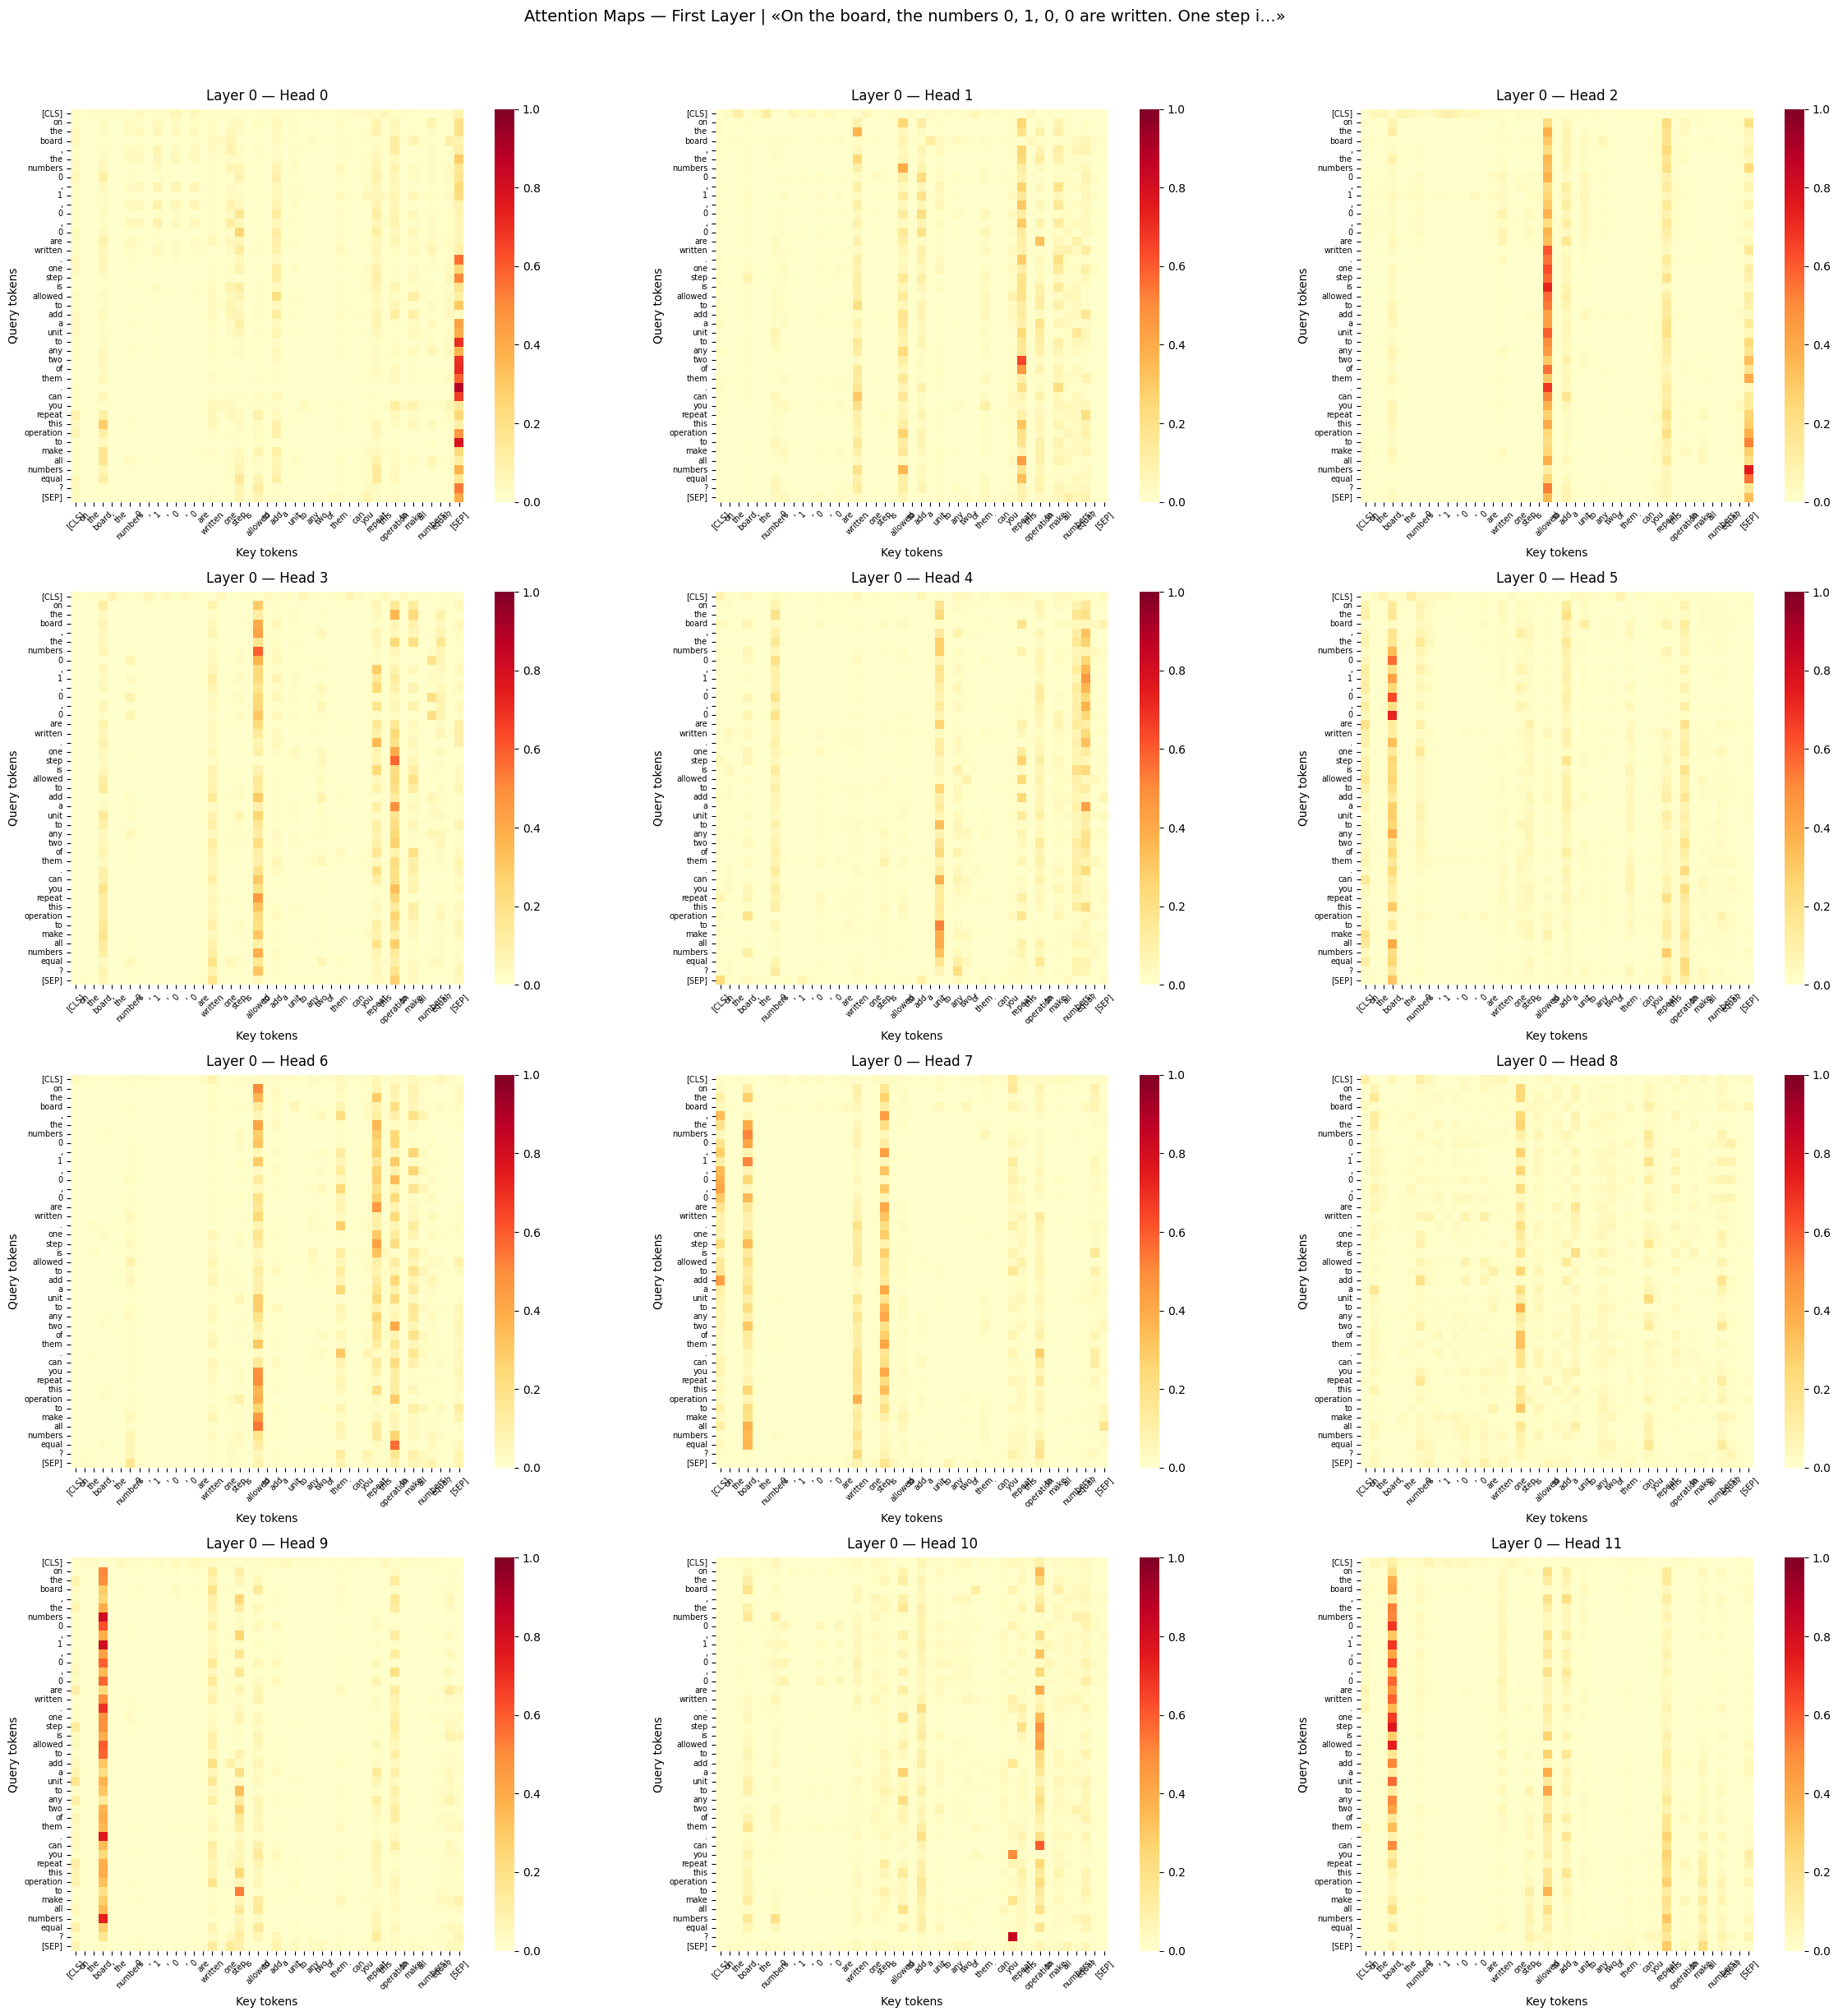

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


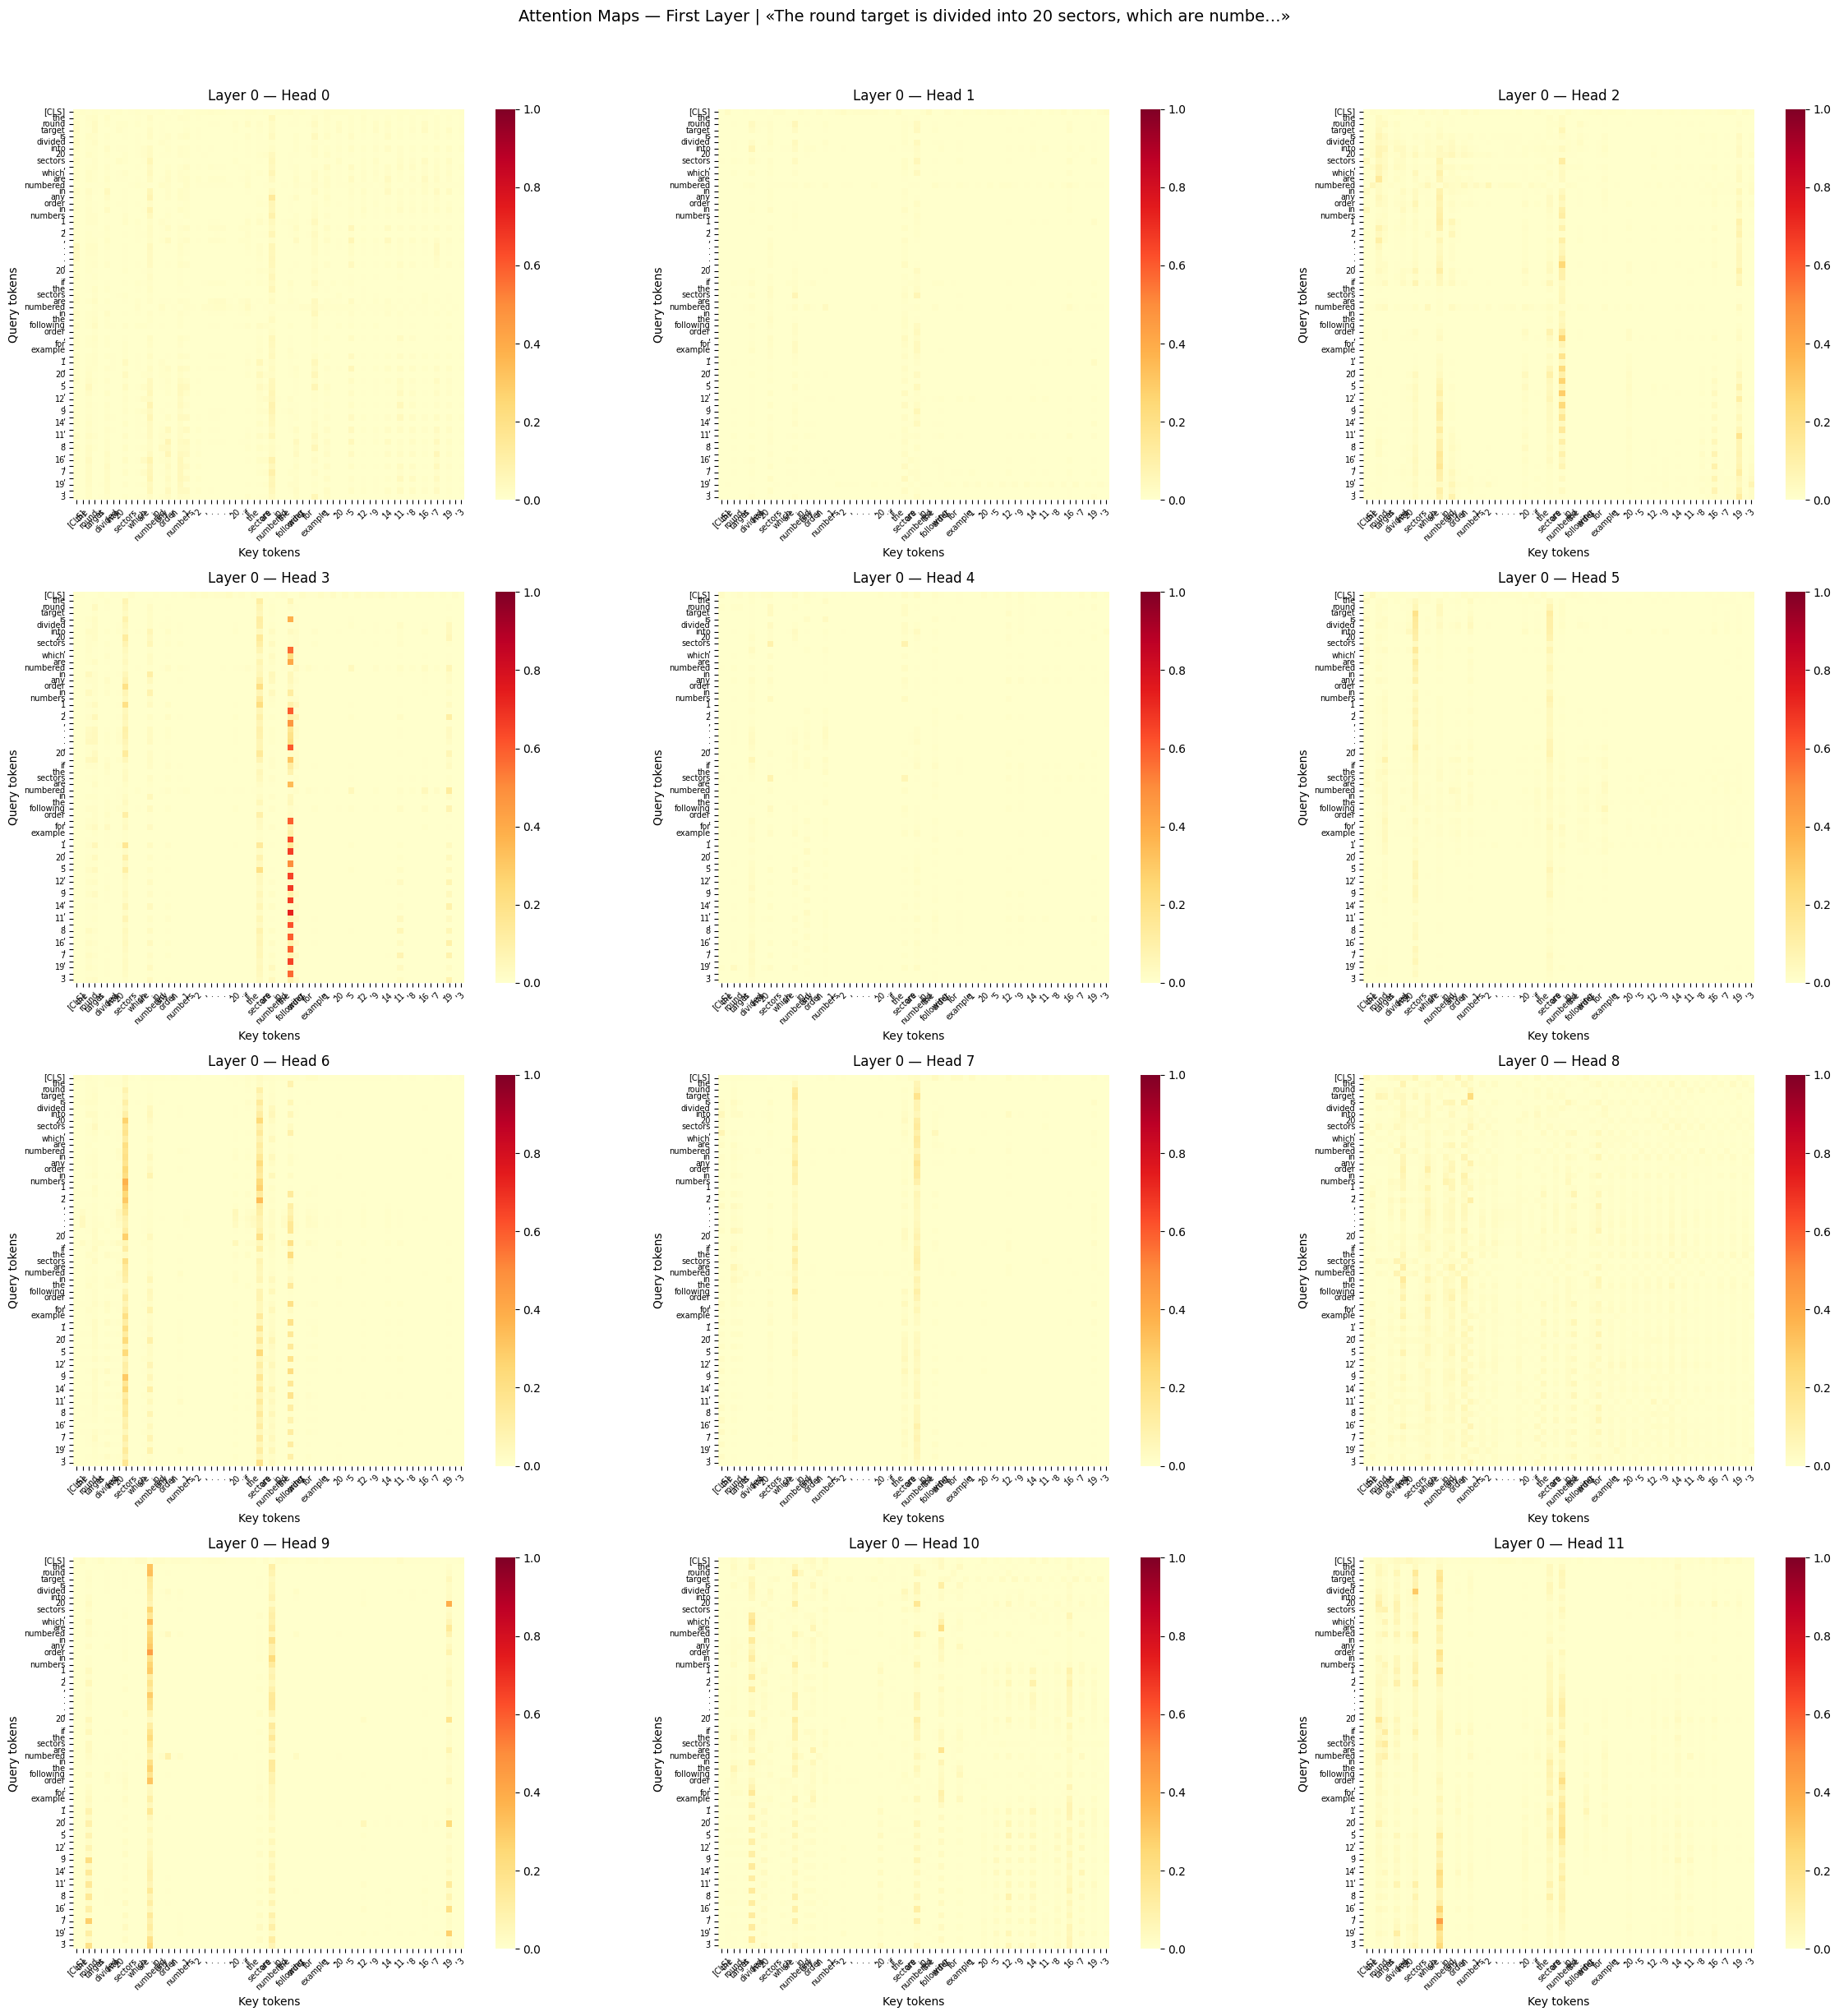

In [44]:
for i in [0, 1, 2]:
  fig = draw_first_layer_attention_maps(
    attention_head_ids=list(range(12)),    # головы для визуализации
    text=small_dataset[i]['problem_text'],
    model=row_mathBert_model,
    tokenizer=mathBert_tokenizer,
    cmap="YlOrRd",
)### YOUR CODE IS HERE

В обеих моделях внимание преимущественно локальное: каждый токен сильнее всего связан с соседними (слева и справа) и с самим собой. Это соответствует литературным данным - первые слои трансформеров обучаются базовой грамматике и порядку слов.

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


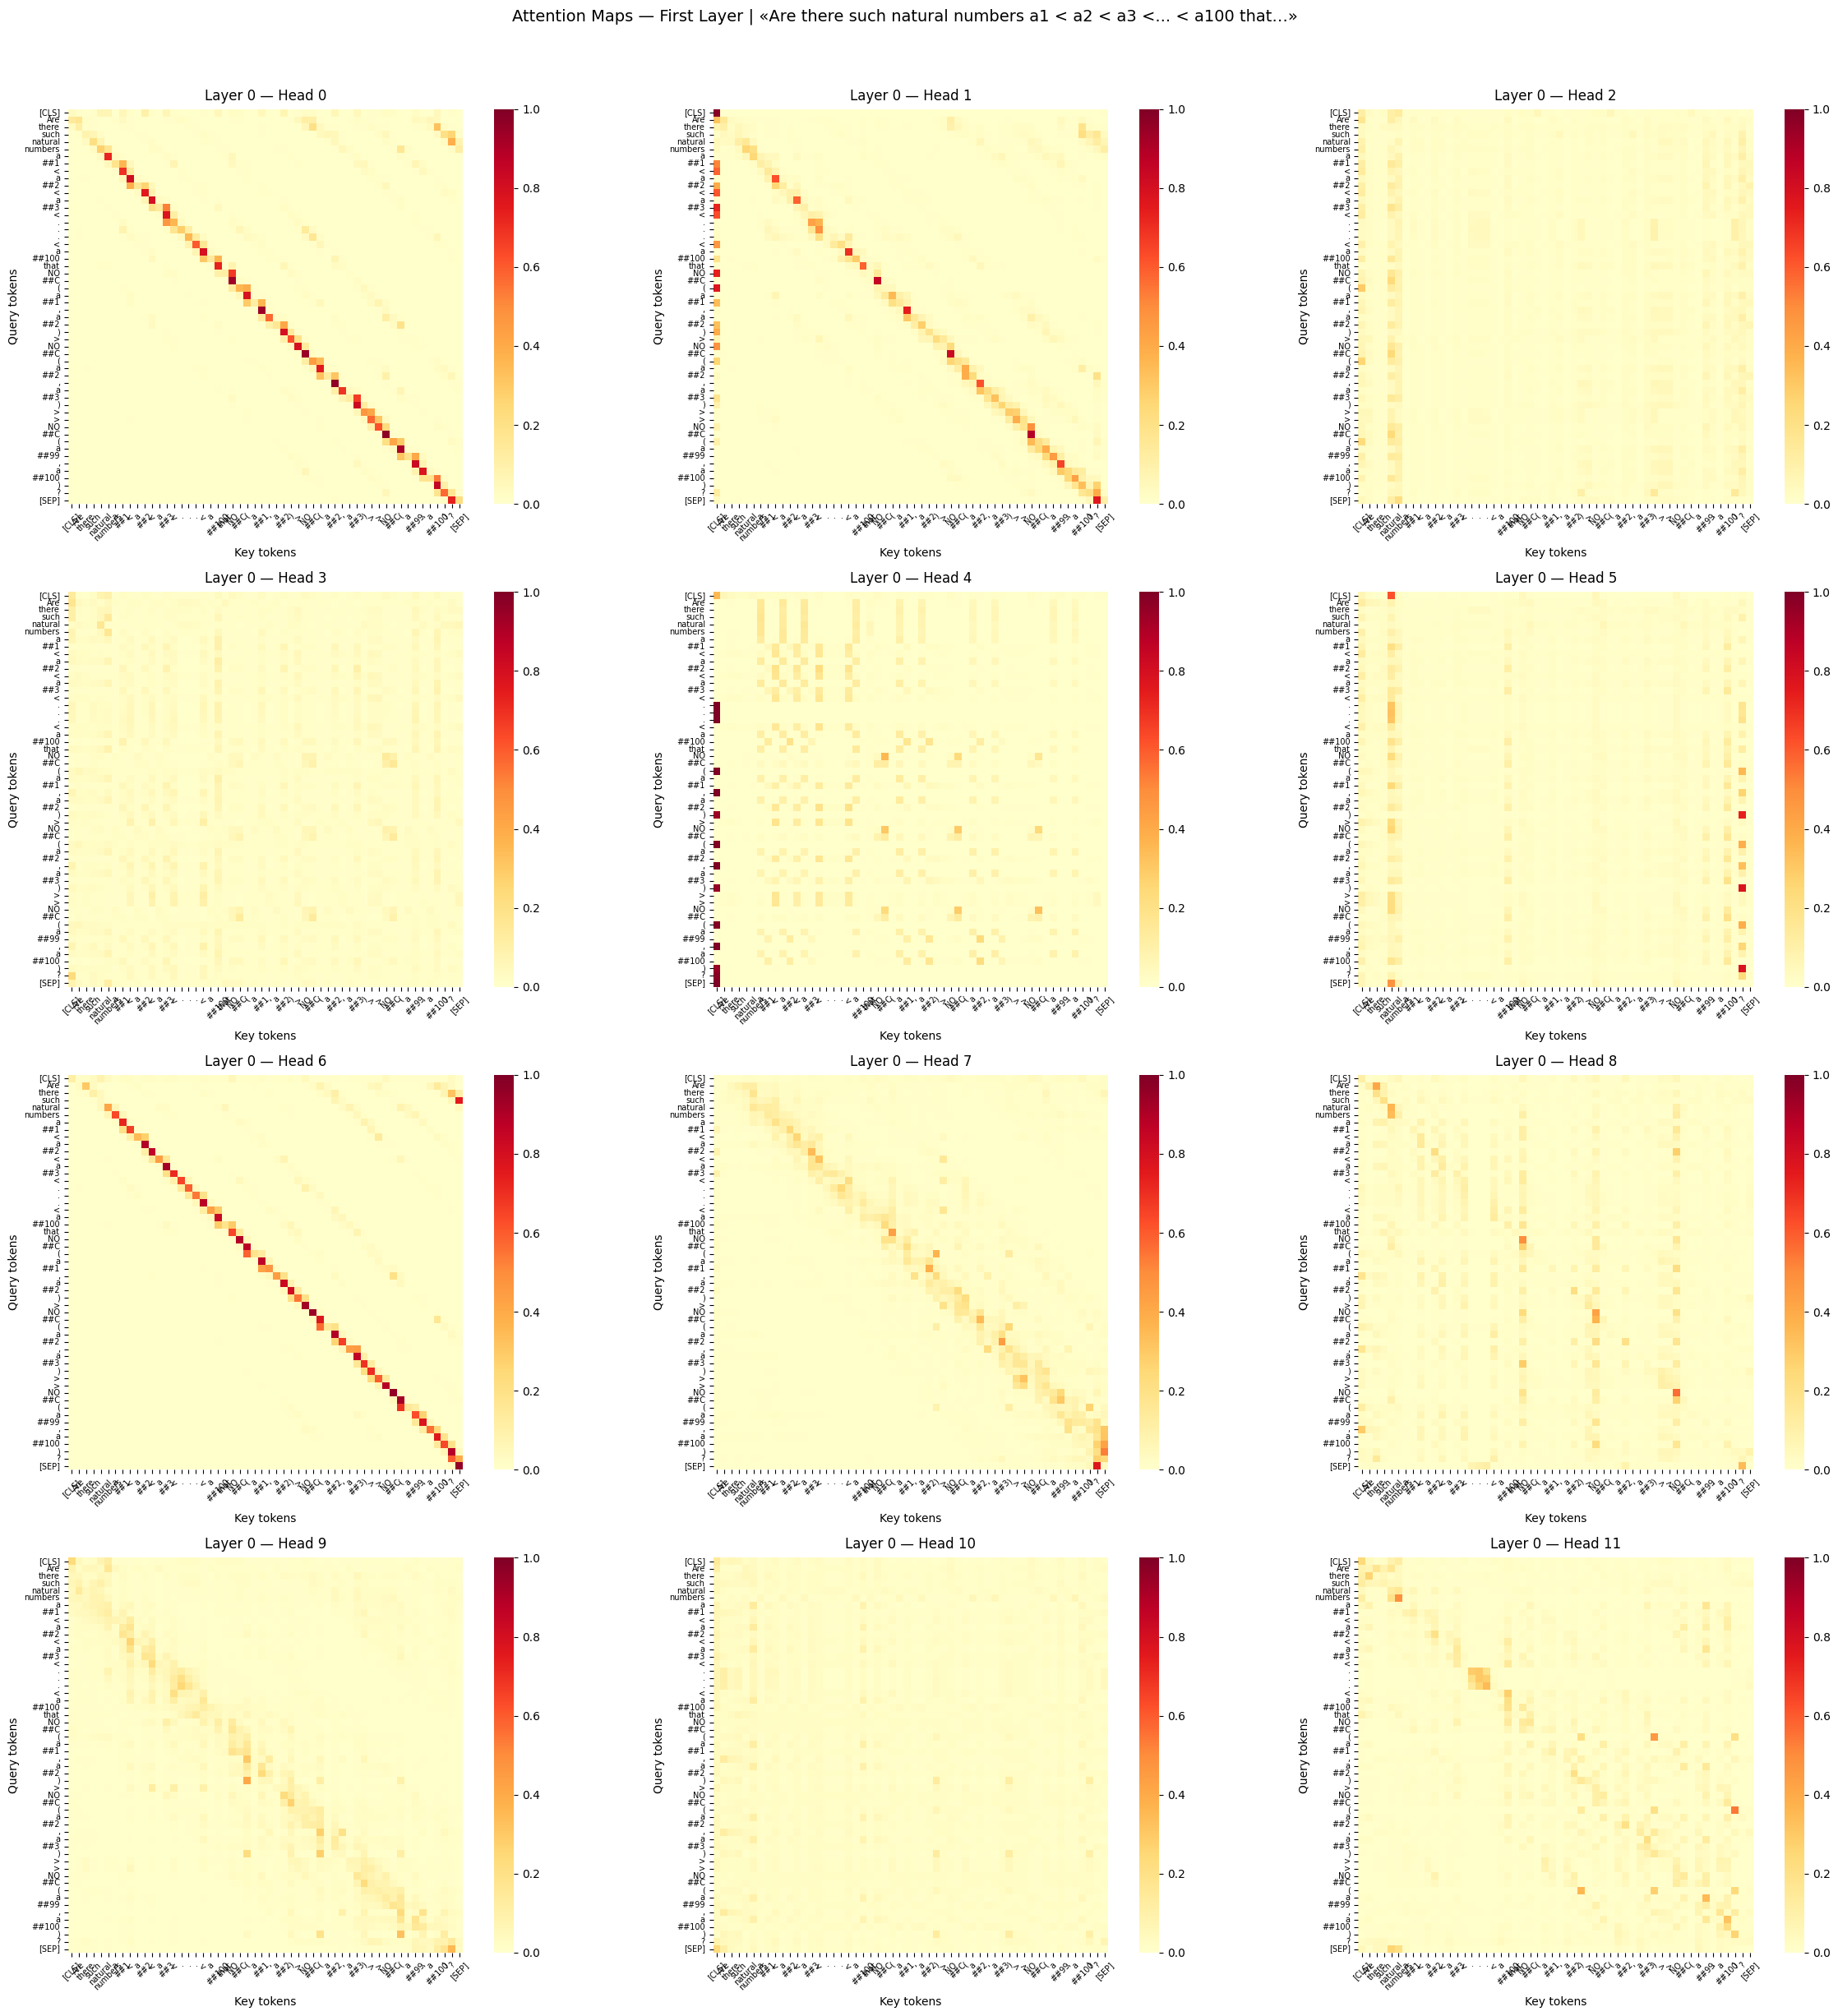

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for i in [0, 1, 2]:
  fig = draw_first_layer_attention_maps(
    attention_head_ids=list(range(12)),    # головы для визуализации
    text=small_dataset[i]['problem_text'],
    model=rubert_tiny_full_finetuned,
    tokenizer=rubert_tiny_tokenizer,
    cmap="YlOrRd",
)### YOUR CODE IS HERE

In [ ]:
for i in [0, 1, 2]]:
  fig = draw_first_layer_attention_maps(
    attention_head_ids=list(range(12)),    # головы для визуализации
    text=small_dataset[i]['problem_text'],
    model=mathBert_full_finetuned,
    tokenizer=mathBert_tokenizer,
    cmap="YlOrRd",
)### YOUR CODE IS HERE

Да, карты внимания дообученной модели отражают не просто язык, а целевую задачу, поэтому они отличаются от карт исходной модели.


Исходная (предобученная) модель видела общий язык и её внимание было настроено на универсальные синтаксические и семантические связи (согласование, дополнения, контекст).
После дообучения на вашей выборке (тексты задач с метками тем) модель научилась выделять именно те слова и конструкции, которые важны для классификации: маркеры тем, ключевые термины, паттерны формулировок.